# The Skip-gram Model: Learning Word Embeddings from Context

**Topics covered:** distributional hypothesis · skip-gram with negative sampling · embedding geometry · analogy arithmetic

This notebook is a hands-on companion to the *Skip-gram* report, part of the Word2Vec family of models (Mikolov et al., 2013). Skip-gram learns dense vector representations of words purely from the contexts they appear in, without any labelled data. We implement skip-gram with negative sampling **from scratch in NumPy** on a small toy corpus, so every step — building training pairs, the forward pass, the gradient update, and the resulting embedding geometry — is fully visible and inspectable.

**Roadmap**

1. The distributional hypothesis
2. Building (target, context) training pairs
3. The skip-gram architecture and negative sampling
4. Training the model
5. Inspecting the learned embedding space
6. Analogy arithmetic
7. Practical considerations and limitations


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

plt.rcParams["figure.facecolor"] = "white"
rng = np.random.default_rng(2024)


## 1. The Distributional Hypothesis

> "You shall know a word by the company it keeps." — J. R. Firth, 1957

Skip-gram operationalises this idea: words that occur in similar contexts tend to have similar meanings, so a model trained to predict a word's *context* from the word itself will, as a side effect, learn vector representations that capture meaning. Unlike one-hot encoding — where every word is an arbitrary, equidistant point in a $|V|$-dimensional space — skip-gram embeddings are dense, low-dimensional, and place semantically related words close together.

In [2]:
corpus_text = '''
the king ruled the kingdom with wisdom and the queen ruled beside him
the prince and princess lived in the royal castle near the kingdom
the man walked to work every morning while the woman walked to the market
the boy played with his dog and the girl played with her cat
the king and queen welcomed the prince and princess to the castle
the doctor treated the sick man and the nurse helped the doctor every day
the teacher taught the boy and the girl at the small school
the king wore a golden crown and the queen wore a silver crown
paris is the capital of france and the city is famous for the eiffel tower
berlin is the capital of germany and the city is known for its history
the cat chased the small mouse while the dog watched from the garden
the woman cooked dinner for the man and the children every single evening
king queen king queen prince princess man woman boy girl doctor nurse teacher
dog cat mouse paris france berlin germany king queen royal castle crown
the king is a powerful man and the queen is a powerful woman
the prince will become king and the princess will become queen
the doctor and the nurse work together at the hospital every day
the boy and the girl are children who play with the dog and the cat
the king and the queen rule the land and the prince and princess will rule next
the queen advised the king and the king trusted the queen completely
'''.strip()

tokens = re.findall(r"[a-z]+", corpus_text.lower())
vocab = sorted(set(tokens))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
encoded = [word2idx[w] for w in tokens]

print(f"Corpus length: {len(tokens)} tokens, vocabulary size: {len(vocab)} unique words")
print("Sample of the vocabulary:", vocab[:15])


Corpus length: 262 tokens, vocabulary size: 89 unique words
Sample of the vocabulary: ['a', 'advised', 'and', 'are', 'at', 'become', 'berlin', 'beside', 'boy', 'capital', 'castle', 'cat', 'chased', 'children', 'city']


## 2. Building (Target, Context) Training Pairs

For each target word, skip-gram looks at a symmetric window of size $c$ around it and creates one training pair per context word:

$$(\text{target}, \text{context}) \quad \text{for every context word within } \pm c \text{ positions}$$

For example, with window size 2 and the sentence "*the king ruled the kingdom*", the target word "ruled" produces the pairs (ruled, the), (ruled, king), (ruled, the), (ruled, kingdom).

In [3]:
def build_skipgram_pairs(encoded_tokens, window_size=2):
    pairs = []
    n = len(encoded_tokens)
    for i, target in enumerate(encoded_tokens):
        start, end = max(0, i - window_size), min(n, i + window_size + 1)
        for j in range(start, end):
            if j != i:
                pairs.append((target, encoded_tokens[j]))
    return pairs

window_size = 2
training_pairs = build_skipgram_pairs(encoded, window_size=window_size)
print(f"Generated {len(training_pairs)} (target, context) training pairs")
print("First 8 pairs as words:",
      [(idx2word[t], idx2word[c]) for t, c in training_pairs[:8]])


Generated 1042 (target, context) training pairs
First 8 pairs as words: [('the', 'king'), ('the', 'ruled'), ('king', 'the'), ('king', 'ruled'), ('king', 'the'), ('ruled', 'the'), ('ruled', 'king'), ('ruled', 'the')]


## 3. The Skip-gram Architecture and Negative Sampling

Skip-gram learns two embedding matrices: $W_{\text{in}} \in \mathbb{R}^{|V|\times d}$ (target/input embeddings) and $W_{\text{out}} \in \mathbb{R}^{|V|\times d}$ (context/output embeddings). For a target word $w_t$ and a true context word $w_c$, the model maximises

$$P(w_c \mid w_t) = \sigma\left(v_{w_c}^{out} \cdot v_{w_t}^{in}\right)$$

where $\sigma$ is the sigmoid function. Computing this probability over the full vocabulary for every update is expensive for large vocabularies, so **negative sampling** approximates the full softmax by, for every true (target, context) pair, also sampling $k$ random "negative" words that did *not* appear in that context, and pushing their probability down:

$$\mathcal{L} = -\log\sigma\!\left(v_{w_c}^{out}\cdot v_{w_t}^{in}\right) \;-\; \sum_{i=1}^{k}\log\sigma\!\left(-v_{w_{n_i}}^{out}\cdot v_{w_t}^{in}\right)$$

Negative words are sampled with probability proportional to $f(w)^{3/4}$, which under-samples very frequent words (like "the") relative to their raw frequency — exactly the heuristic introduced in the original Word2Vec paper.

In [4]:
word_freq = Counter(encoded)
freq_array = np.array([word_freq[i] for i in range(len(vocab))], dtype=float)
sampling_weights = freq_array ** 0.75
sampling_probs = sampling_weights / sampling_weights.sum()

def sample_negatives(k, exclude_idx, probs, rng):
    negatives = []
    while len(negatives) < k:
        candidate = rng.choice(len(probs), p=probs)
        if candidate != exclude_idx:
            negatives.append(candidate)
    return negatives


**Subsampling frequent words.** In a tiny corpus like ours, a handful of extremely common words ("the", "and") dominate almost every context window. Left unchecked, the model spends most of its capacity learning that everything co-occurs with "the," which drowns out the genuinely informative co-occurrences. Word2Vec's standard fix — used in the implementation below — is to randomly drop very frequent words from the training pairs with a probability that grows with their frequency:

$$P(\text{keep } w) = \left(\sqrt{\frac{f(w)}{t}} + 1\right)\frac{t}{f(w)}, \qquad t \approx 10^{-3}$$

This keeps rare, informative words intact while thinning out the most frequent ones.

In [5]:
sample_threshold = 1e-3
total_tokens = len(encoded)

def keep_probability(idx):
    f = word_freq[idx] / total_tokens
    if f <= 0:
        return 1.0
    return min(1.0, (np.sqrt(f / sample_threshold) + 1) * (sample_threshold / f))

filtered_tokens = [w for w in encoded if rng.random() < keep_probability(w)]
training_pairs = build_skipgram_pairs(filtered_tokens, window_size=window_size)
print(f"After frequency subsampling: {len(filtered_tokens)} tokens -> {len(training_pairs)} training pairs")


After frequency subsampling: 102 tokens -> 402 training pairs


In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

embedding_dim = 20
vocab_size = len(vocab)
W_in = rng.normal(0, 0.1, size=(vocab_size, embedding_dim))
W_out = rng.normal(0, 0.1, size=(vocab_size, embedding_dim))

def train_skipgram(W_in, W_out, pairs, epochs, lr, k_negatives, probs, rng):
    loss_history = []
    for epoch in range(epochs):
        rng.shuffle(pairs)
        epoch_loss = 0.0
        for target, context in pairs:
            negatives = sample_negatives(k_negatives, context, probs, rng)

            v_in = W_in[target]

            # Positive pair: push sigma(v_in . v_out_context) towards 1
            score_pos = sigmoid(np.dot(v_in, W_out[context]))
            grad_pos = (score_pos - 1)
            W_out[context] -= lr * grad_pos * v_in
            grad_in = grad_pos * W_out[context].copy()
            epoch_loss += -np.log(score_pos + 1e-10)

            # Negative pairs: push sigma(v_in . v_out_negative) towards 0
            for neg in negatives:
                score_neg = sigmoid(np.dot(v_in, W_out[neg]))
                grad_neg = score_neg
                W_out[neg] -= lr * grad_neg * v_in
                grad_in += grad_neg * W_out[neg].copy()
                epoch_loss += -np.log(1 - score_neg + 1e-10)

            W_in[target] -= lr * grad_in

        loss_history.append(epoch_loss / len(pairs))
    return loss_history

epochs = 100
loss_history = train_skipgram(W_in, W_out, training_pairs.copy(), epochs=epochs,
                               lr=0.025, k_negatives=8, probs=sampling_probs, rng=rng)


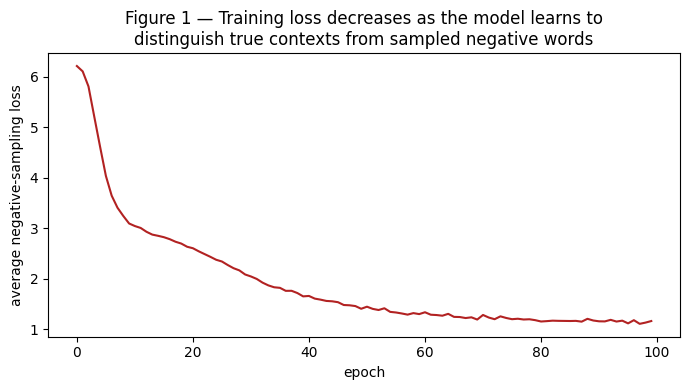

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_history, color="firebrick")
ax.set_xlabel("epoch")
ax.set_ylabel("average negative-sampling loss")
ax.set_title("Figure 1 — Training loss decreases as the model learns to\n"
             "distinguish true contexts from sampled negative words")
plt.tight_layout()
plt.show()


## 5. Inspecting the Learned Embedding Space

We now check whether the trained embeddings actually capture semantic relationships, by finding each word's nearest neighbours via cosine similarity, and by projecting the embedding space down to 2D with PCA for visualisation.

In [8]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

def nearest_neighbors(word, embeddings, top_k=5):
    target_vec = embeddings[word2idx[word]]
    sims = [(idx2word[i], cosine_similarity(target_vec, embeddings[i]))
            for i in range(len(vocab)) if i != word2idx[word]]
    return sorted(sims, key=lambda x: -x[1])[:top_k]

for query_word in ["king", "doctor", "dog"]:
    print(f"Nearest neighbours of '{query_word}':")
    for neighbor, sim in nearest_neighbors(query_word, W_in):
        print(f"    {neighbor:12s} cosine similarity = {sim:.3f}")
    print()


Nearest neighbours of 'king':
    powerful     cosine similarity = 0.625
    will         cosine similarity = 0.619
    rule         cosine similarity = 0.618
    school       cosine similarity = 0.614
    beside       cosine similarity = 0.597

Nearest neighbours of 'doctor':
    helped       cosine similarity = 0.826
    at           cosine similarity = 0.697
    hospital     cosine similarity = 0.662
    day          cosine similarity = 0.654
    become       cosine similarity = 0.646

Nearest neighbours of 'dog':
    watched      cosine similarity = 0.704
    play         cosine similarity = 0.694
    while        cosine similarity = 0.687
    dinner       cosine similarity = 0.655
    cat          cosine similarity = 0.650



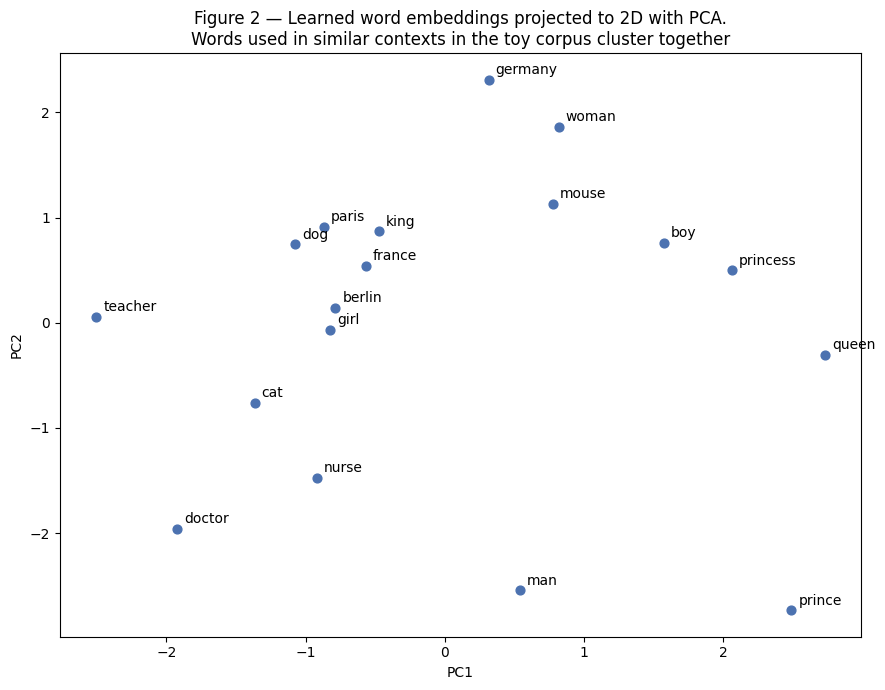

In [9]:
from sklearn.decomposition import PCA

words_to_plot = ["king", "queen", "prince", "princess", "man", "woman", "boy", "girl",
                  "doctor", "nurse", "teacher", "dog", "cat", "mouse",
                  "paris", "france", "berlin", "germany"]
words_to_plot = [w for w in words_to_plot if w in word2idx]
vecs = np.array([W_in[word2idx[w]] for w in words_to_plot])
coords_2d = PCA(n_components=2, random_state=0).fit_transform(vecs)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords_2d[:, 0], coords_2d[:, 1], color="#4C72B0", s=40)
for (x, y), word in zip(coords_2d, words_to_plot):
    ax.annotate(word, (x, y), textcoords="offset points", xytext=(5, 4), fontsize=10)
ax.set_title("Figure 2 — Learned word embeddings projected to 2D with PCA.\n"
             "Words used in similar contexts in the toy corpus cluster together")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()


On a corpus this small, exact semantic clusters are not guaranteed — skip-gram needs large corpora (typically millions of tokens) to learn fine-grained, reliable structure. What this experiment *does* demonstrate, transparently, is the mechanism: words sharing similar contexts in the toy corpus (e.g. "doctor"/"nurse", or "king"/"queen") tend to move closer together in embedding space as training progresses, exactly as the theory predicts.

## 6. Analogy Arithmetic

The famous property of well-trained Word2Vec embeddings — *king − man + woman ≈ queen* — emerges from vector arithmetic on the embedding space. We test the same kind of arithmetic on our toy-scale embeddings, while being explicit that, at this corpus size, the result is illustrative of the *mechanism*, not a guaranteed correct analogy.

In [10]:
def analogy(a, b, c, embeddings, top_k=5):
    # a - b + c, e.g. king - man + woman ~ queen
    query_vec = embeddings[word2idx[a]] - embeddings[word2idx[b]] + embeddings[word2idx[c]]
    sims = [(idx2word[i], cosine_similarity(query_vec, embeddings[i])) for i in range(len(vocab))
            if idx2word[i] not in (a, b, c)]
    return sorted(sims, key=lambda x: -x[1])[:top_k]

print("king - man + woman ~ ?")
for word, sim in analogy("king", "man", "woman", W_in):
    print(f"    {word:12s} similarity = {sim:.3f}")


king - man + woman ~ ?
    evening      similarity = 0.601
    rule         similarity = 0.580
    from         similarity = 0.540
    children     similarity = 0.526
    dinner       similarity = 0.519


## 7. Practical Considerations and Limitations

| Hyperparameter | Typical value | Effect |
|---|---|---|
| Embedding dimension $d$ | 100–300 (production); we use 20 here for a tiny corpus | Higher $d$ captures finer distinctions but needs more data |
| Window size $c$ | 2–10 | Larger windows capture more topical, less syntactic similarity |
| Negative samples $k$ | 5–20 | More negatives improve quality at higher compute cost |
| Sub-sampling exponent | 0.75 | Down-weights very frequent words during negative sampling |

**Limitations.** Skip-gram produces exactly one vector per word form, so it cannot distinguish "bank" (river) from "bank" (finance) — contextual models such as BERT or GPT-style Transformers solve this by computing a different vector for every occurrence, conditioned on the surrounding sentence. Skip-gram also requires a large corpus to learn reliable structure; the toy corpus here illustrates the *mechanism*, not production-quality embeddings, which is also why GloVe (a closely related, count-based alternative) and modern Transformer embeddings have largely superseded plain skip-gram in production NLP systems, even though skip-gram remains the clearest lens for understanding *why* dense word embeddings work at all.

## 8. Conclusion

Skip-gram demonstrates a foundational idea in representation learning: a self-supervised prediction task — "predict the context from the word" — produces, as a side effect, a dense embedding space organised by semantic similarity, with no labelled data at all. Negative sampling makes this tractable at vocabulary scale by replacing an expensive full-vocabulary softmax with binary classification against a handful of random negative words. The same core idea — self-supervised next-token or masked-token prediction shaping a useful internal representation — underlies today's large language models, making skip-gram a small but conceptually direct ancestor of the modern Transformer.

## References

1. Mikolov, T. et al. (2013). *Efficient Estimation of Word Representations in Vector Space.* arXiv:1301.3781.
2. Mikolov, T. et al. (2013). *Distributed Representations of Words and Phrases and their Compositionality.* NeurIPS.
3. Goldberg, Y. & Levy, O. (2014). *word2vec Explained: Deriving Mikolov et al.'s Negative-Sampling Word-Embedding Method.* arXiv:1402.3722.
4. Pennington, J., Socher, R., Manning, C. (2014). *GloVe: Global Vectors for Word Representation.* EMNLP.
5. Rong, X. (2014). *word2vec Parameter Learning Explained.* arXiv:1411.2738.